In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/raw/nlp_reviews.csv"
)

df.head()

,feedback,sentiment
0,"a stirring , funny and finally transporting re...",positive
1,apparently reassembled from the cutting room f...,negative
2,they presume their audience wo n't sit still f...,negative
3,this is a visually stunning rumination on love...,positive
4,jonathan parker 's bartleby should have been t...,positive


In [7]:
def classify_issue(feedback):

    feedback = str(feedback).lower()

    if "rude" in feedback or "behavior" in feedback:

        return "Driver Behavior Issue"

    elif "late" in feedback or "delay" in feedback:

        return "Late Arrival"

    elif "dirty" in feedback or "smell" in feedback:

        return "Vehicle Cleanliness"

    elif "expensive" in feedback or "price" in feedback:

        return "Pricing Complaint"

    elif "cancel" in feedback:

        return "Ride Cancellation"

    elif "app" in feedback or "bug" in feedback:

        return "Application Issue"

    else:

        return "General Feedback"

In [8]:
df['issue_type'] = df['feedback'].apply(
    classify_issue
)

df[[
    'feedback',
    'sentiment',
    'issue_type'
]].head(10)

,feedback,sentiment,issue_type
0,"a stirring , funny and finally transporting re...",positive,General Feedback
1,apparently reassembled from the cutting room f...,negative,Application Issue
2,they presume their audience wo n't sit still f...,negative,Application Issue
3,this is a visually stunning rumination on love...,positive,General Feedback
4,jonathan parker 's bartleby should have been t...,positive,General Feedback
5,campanella gets the tone just right funny in t...,positive,General Feedback
6,a fan film that for the uninitiated plays bett...,negative,General Feedback
7,"b art and berling are both superb , while hupp...",positive,General Feedback
8,"a little less extreme than in the past , with ...",negative,General Feedback
9,the film is strictly routine,negative,General Feedback


In [9]:
df['issue_type'].value_counts()

issue_type
General Feedback         6502
Application Issue         279
Late Arrival               93
Driver Behavior Issue      21
Pricing Complaint          14
Vehicle Cleanliness        11
Name: count, dtype: int64

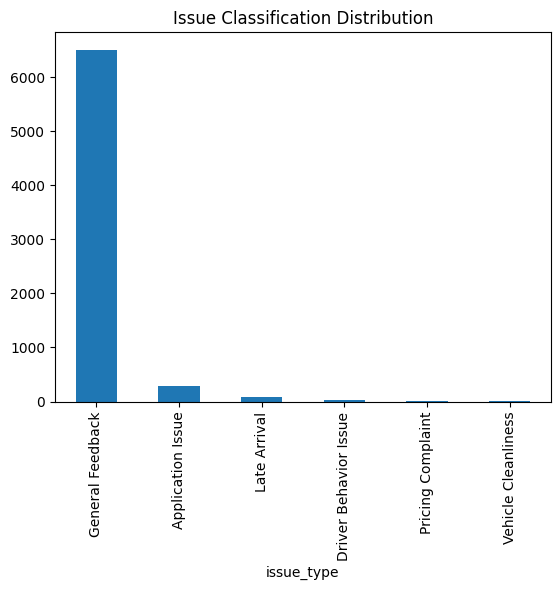

In [10]:
import matplotlib.pyplot as plt

df['issue_type'].value_counts().plot(

    kind='bar'

)

plt.title(
    "Issue Classification Distribution"
)

plt.show()

In [13]:
rides = pd.read_csv(
    r"D:\Guvi\Projects\ride_flow_ai\data\preprocessed\cleaned_rides.csv"
)

rides.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_hour,pickup_day,pickup_weekday,pickup_month,is_weekend,trip_duration
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,...,1.0,22.70,2.5,0.0,0,1,0,1,0,19.800000
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,...,1.0,18.75,2.5,0.0,0,1,0,1,0,6.600000
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,...,1.0,31.30,2.5,0.0,0,1,0,1,0,17.916667
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,...,1.0,17.00,2.5,0.0,0,1,0,1,0,8.300000
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,...,1.0,16.10,2.5,0.0,0,1,0,1,0,6.100000


In [14]:
import numpy as np

np.random.seed(42)

rides['driver_rating'] = np.random.uniform(

    3.5,

    5.0,

    len(rides)
)

rides['eta'] = np.random.randint(

    2,

    20,

    len(rides)
)

rides['cancellation_risk'] = np.random.uniform(

    0,

    1,

    len(rides)
)

In [15]:
rides['match_score'] = (

    rides['driver_rating'] * 0.5

    -

    rides['eta'] * 0.1

    -

    rides['cancellation_risk'] * 2
)

In [16]:
top_drivers = rides.sort_values(

    by='match_score',

    ascending=False
)

top_drivers[[
    'driver_rating',
    'eta',
    'cancellation_risk',
    'match_score'
]].head()

,driver_rating,eta,cancellation_risk,match_score
64917,4.997195,2,0.009232,2.280133
89101,4.978495,2,0.011398,2.266451
94555,4.952982,2,0.014780,2.246930
63247,4.997099,2,0.029777,2.238995
61289,4.911954,2,0.008586,2.238805


In [17]:
responses = {

    "refund":"Refund will be processed within 3-5 business days.",

    "booking":"Your ride booking has been confirmed.",

    "cancel":"You can cancel your ride before driver arrival.",

    "driver":"Your assigned driver is arriving shortly.",

    "payment":"Payment support request has been generated.",

    "eta":"Estimated arrival time is available in the app.",

    "price":"Dynamic pricing depends on demand and traffic."
}

In [18]:
def chatbot(query):

    query = query.lower()

    for key in responses:

        if key in query:

            return responses[key]

    return "Please contact RideFlow AI customer support."